133009000000.0


[*********************100%***********************]  3 of 3 completed


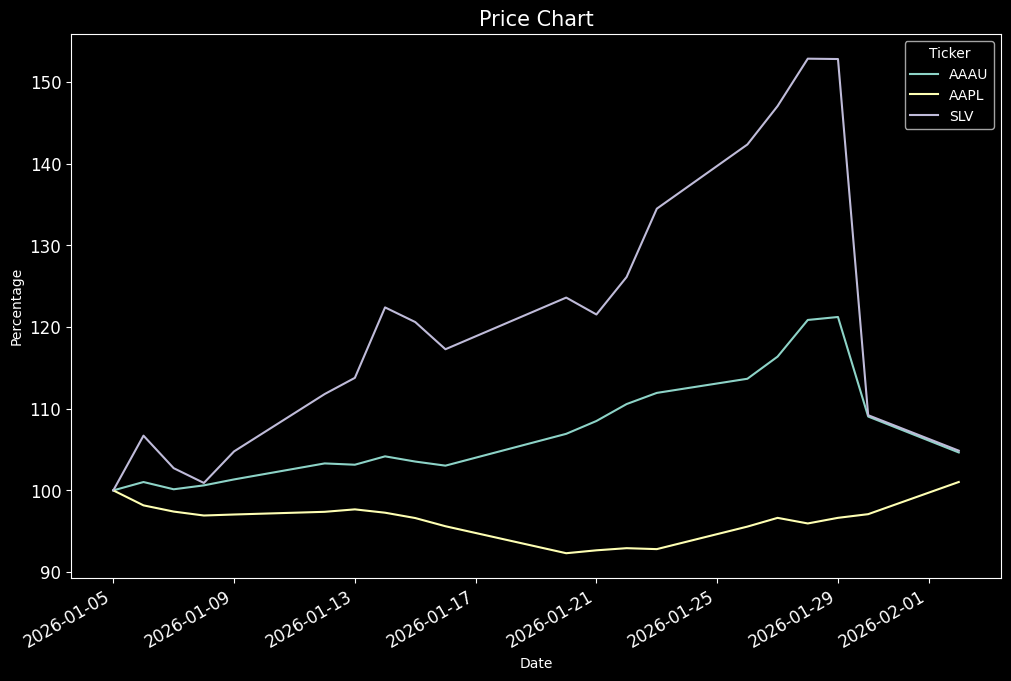

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

microsoft = yf.Ticker('MSFT')
microsoft.income_stmt
microsoft.balance_sheet
microsoft.cash_flow

#print(microsoft.income_stmt)
print(microsoft.income_stmt["2024-06-30"]["EBITDA"])

#
# print(microsoft.quarterly_income_stmt)
# print(microsoft.quarterly_balance_sheet)
# print(microsoft.quarterly_cash_flow)

info = pd.Series(microsoft.info)

# print(info)
# print(info.keys())
# print(info.currentPrice)
# print(info.marketCap)
# print(info.trailingPE)

def collect_ratios(tickers: list, ratios: list):
    rows = []

    for ticker in tickers:
        info = yf.Ticker(ticker).info
        row = [ticker] + [info.get(ratio, None) for ratio in ratios]
        rows.append(row)

    return pd.DataFrame(rows, columns=["Ticker"] + ratios)

collect_ratios(["WMT", "MO", "NVDA", "CRM"], ["sector", "industry",
 "currentRatio", "quickRatio"])


def plot_closing_prices(data):

    close_prices = data["Close"]
    price_change_in_percentage = (close_prices / close_prices.iloc[0] * 100)
    price_change_in_percentage.plot(figsize = (12,8), fontsize = 12)
    plt.ylabel("Percentage")
    plt.title(f"Price Chart", fontsize = 15)
    plt.show()


hist_prices_2023 = yf.Tickers(["AAPL", "AAAU", "SLV"]).history()
plot_closing_prices(hist_prices_2023)
# render_ticker(['AAPL', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'INTC', 'AMD', 'IBM'])
